# Quantum Dots: From Photoluminescence Spectra to Models and Classification

In this lab, you will work with **photoluminescence spectra** for semiconductor quantum dots made of **CdS, CdSe, and CdTe**. Each file contains one spectrum with a single emission peak. Your goal is to extract the peak wavelength from each spectrum, convert that wavelength into an excitation energy, and then study how that energy changes with quantum dot radius.

You will then compare increasingly sophisticated models of confinement and use a simple machine learning workflow to classify the material from the measured radius and excitation energy.

---

**Chemistry Learning Objectives**
- C4.1: Explain how a photoluminescence spectrum encodes the characteristic excitation energy of a quantum dot.
- C4.2: Relate quantum dot radius to confinement-driven changes in emission wavelength and excitation energy.
- C4.3: Interpret simple and extended confinement models in terms of the physics they include or neglect.
- C4.4: Compare CdS, CdSe, and CdTe using fitted trends in excitation energy versus radius.

**Programming Learning Objectives**
- P4.1: Use helper functions and reusable workflows to analyze many spectra efficiently.
- P4.2: Transform one-file analysis code into a full-table data-processing workflow.
- P4.3: Translate mathematical models into Python functions and compare fits quantitatively.
- P4.4: Use Scikit-Learn for a basic classification task with tabular scientific data.

---

**Table of Contents**
- [Warmup - A first look at classification](#warmup) `20 points`
- [Part 1 - Loading and interpreting one spectrum](#part1) `20 points`
- [Part 2 - Processing all of the spectra](#part2) `20 points`
- [Part 3 - Modeling excitation energy vs radius](#part3) `30 points`
- [Part 4 - Classification with machine learning](#part4) `20 points`
- [Reflection](#reflection) `10 points`

`Total: 120 points`

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import curve_fit

<a id="warmup"></a>
## Warmup - A first look at classification

In this warmup, you will practice building and comparing classification models using a simple three-class dataset. The goal is not technical rigor yet. Instead, the goal is to get comfortable with the Scikit-Learn workflow you will use again in Part 4.

### Coding Activity (Warmup) `10 points`

- P1: Use Scikit-Learn for a simple classification task.
- C4: Compare how different materials occupy different regions of a data set.

You will begin with a worked example and then try a second model yourself.


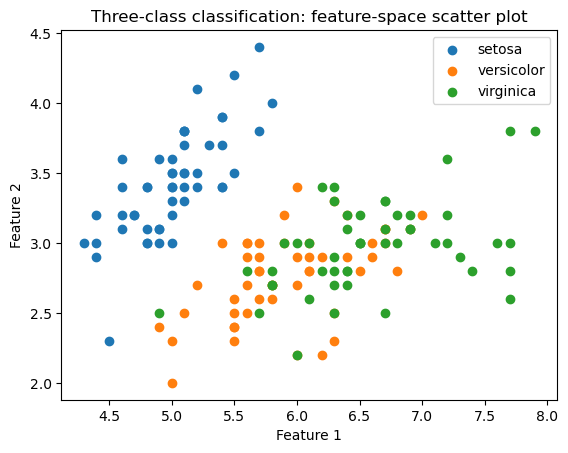

In [2]:
# Imports for the warmup classification task.
from helper import plot_predictions_vs_truth
from sklearn.datasets import load_iris
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Load a three-class dataset and build a two-feature summary table.
iris = load_iris()
warmup_df = pd.DataFrame(iris.data[:, :2], columns=['feature_1', 'feature_2'])
warmup_df['label'] = [iris.target_names[t] for t in iris.target]

# Scatter plot: do the three classes separate cleanly in this two-feature space?
for label in iris.target_names:
    subset = warmup_df[warmup_df['label'] == label]
    plt.scatter(subset['feature_1'], subset['feature_2'], label=label)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Three-class classification: feature-space scatter plot")
plt.legend()
plt.show()

#### W.B - Worked example: K-nearest neighbors

The cell below trains a **K-nearest neighbors** classifier on the full warmup table and reports the training accuracy. Read the code, run it, and annotate the comments.

In [3]:
X_warmup = warmup_df[["feature_1", "feature_2"]].values
y_warmup = warmup_df["label"].values

knn_model = make_pipeline(
    StandardScaler(),   # rescales the two input features before classification
    KNeighborsClassifier(n_neighbors=3)
)

knn_model.fit(X_warmup, y_warmup)   # trains the model on the labeled data
knn_pred = knn_model.predict(X_warmup)
knn_acc = accuracy_score(y_warmup, knn_pred)
print(f"KNN training accuracy: {knn_acc:.3f}")

KNN training accuracy: 0.833


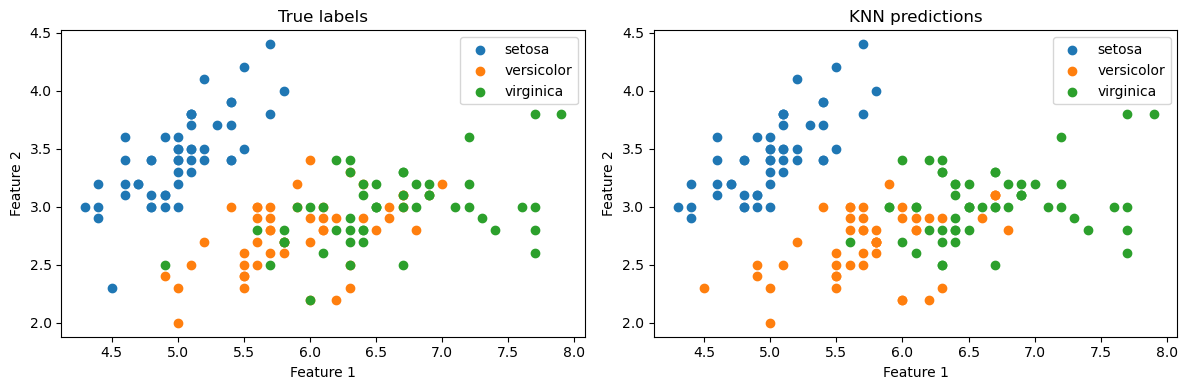

In [4]:

# Show what the model predicts for each point.
plot_predictions_vs_truth(X_warmup, y_warmup, knn_pred, "KNN",
                          xlabel="Feature 1", ylabel="Feature 2")

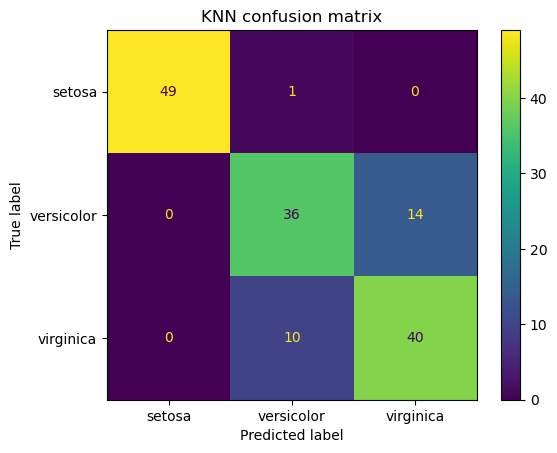

In [5]:
# Confusion matrix: which classes does the model confuse?
cm = confusion_matrix(y_warmup, knn_pred, labels=np.unique(y_warmup))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_warmup))
disp.plot()
plt.title("KNN confusion matrix")
plt.show()

#### W.C - Your turn: try a second classifier

Use the starter code below to fit a **logistic regression** classifier to the same features. Then compute the training accuracy, plot the predictions using `plot_predictions_vs_truth`, and generate a confusion matrix.

In [6]:
# Starter code: replace the comments with your own brief explanations.
logreg_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=500)
)

# Subgoal: Fit the model to X_warmup and y_warmup.
logreg_model.fit(X_warmup, y_warmup)

# Subgoal: Generate predictions on the same warmup data.
logreg_pred = logreg_model.predict(X_warmup)

# Subgoal: Compute and print the training accuracy.
logreg_acc = accuracy_score(y_warmup, logreg_pred)
print(f"Logistic regression training accuracy: {logreg_acc:.3f}")

Logistic regression training accuracy: 0.813


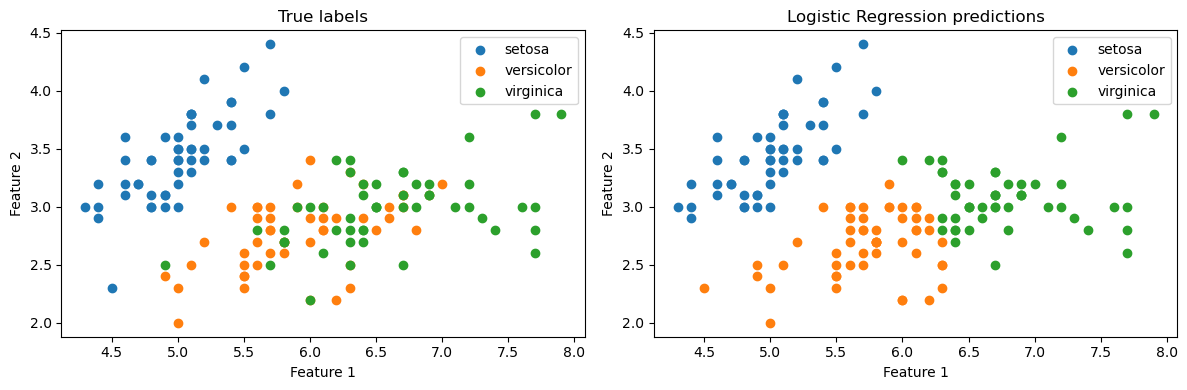

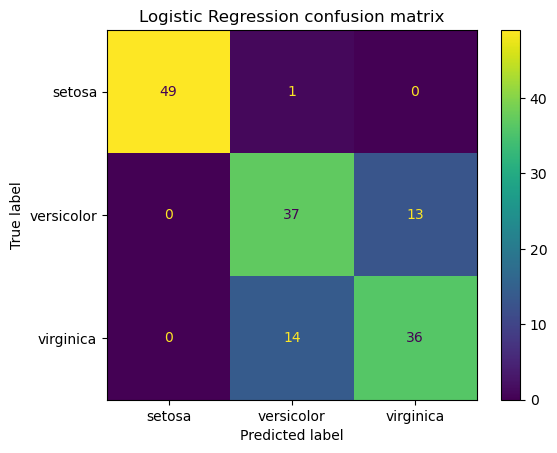

In [7]:
# Compare true labels and predictions.
plot_predictions_vs_truth(X_warmup, y_warmup, logreg_pred, "Logistic Regression",
                          xlabel="Feature 1", ylabel="Feature 2")

# Generate a confusion matrix for the logistic regression model.
cm = confusion_matrix(y_warmup, logreg_pred, labels=np.unique(y_warmup))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_warmup))
disp.plot()
plt.title("Logistic Regression confusion matrix")
plt.show()

### Question (Warmup) `10 points`

- P1: Use Scikit-Learn for a simple classification task.
- C4: Compare how different classes occupy different regions of a data set.

1. Based on the scatter plot, do the three classes appear perfectly separated by these two features alone, or is there overlap?
2. Which warmup classifier seemed more successful on this data? Give one reason that might explain its performance.

*Your answer here (`double click me!`):*

<br></br>

<a id="part1"></a>
## Part 1 - Loading and interpreting one spectrum

Each file in the `data/` folder is a **photoluminescence spectrum** with one dominant peak. In this part, you will load individual spectra, plot them, and extract the peak wavelength. Because the peak corresponds to the emitted photon, it provides a direct route to the characteristic excitation energy:

$$
E = \frac{hc}{\lambda} \approx \frac{1239.84\ \text{eV nm}}{\lambda\,(\text{nm})}.
$$

### Coding Activity 1 `10 points`

- C1: Explain how a photoluminescence spectrum encodes a characteristic excitation energy.
- P2: Decompose a data task into loading, plotting, and extracting a quantity.


#### Part 1A - Worked example: load and plot a single spectrum

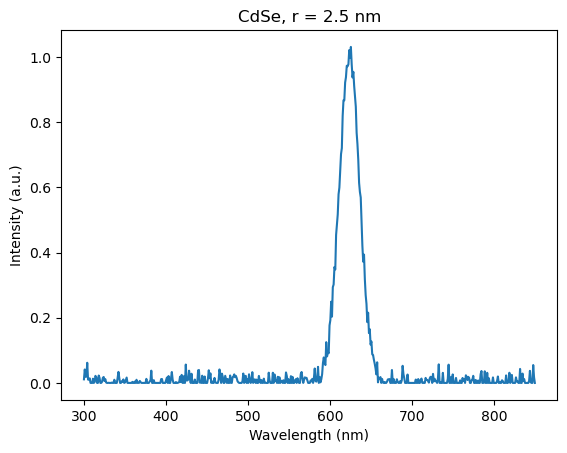

,wavelength_nm,intensity_au
0,300.0000,0.0110
1,301.0018,0.0412
2,302.0036,0.0188
3,303.0055,0.0195
4,304.0073,0.0618


In [8]:
# --- Worked example: load and plot a single spectrum ---
# Subgoal: load the spectrum data from CSV.
name = "CdSe_r2.50nm"
path = os.path.join('data', name + '.csv')
df = pd.read_csv(path, comment='#', names=['wavelength_nm', 'intensity_au'])

# Subgoal: parse material and radius from the filename.
material = name.split('_r')[0]                          # 'CdSe'
radius = float(name.split('_r')[1].replace('nm', ''))   # 2.50

# Subgoal: plot intensity vs. wavelength.
plt.plot(df['wavelength_nm'], df['intensity_au'])
plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity (a.u.)")
plt.title(f"{material}, r = {radius} nm")
plt.show()

display(df.head())

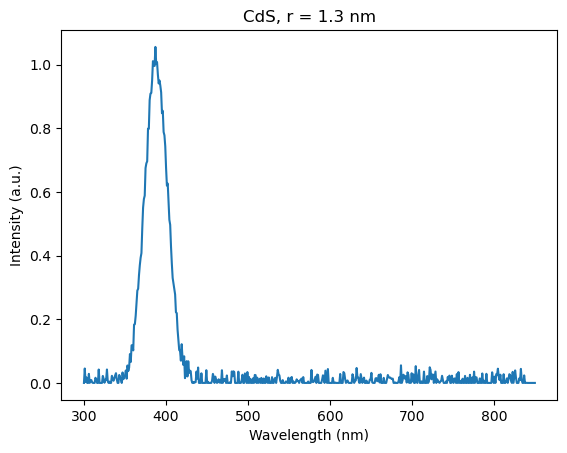

In [9]:
# Subgoal: Load the spectrum data from CSV.
name = "CdS_r1.30nm"
path = os.path.join('data', name + '.csv')
df = pd.read_csv(path, comment='#', names=['wavelength_nm', 'intensity_au'])

# Subgoal: Parse material and radius from the filename.
material = name.split('_r')[0]
radius = float(name.split('_r')[1].replace('nm', ''))

# Subgoal: Plot the spectrum.
plt.plot(df['wavelength_nm'], df['intensity_au'])
plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity (a.u.)")
plt.title(f"{material}, r = {radius} nm")
plt.show()

#### Part 1B - Extract the peak wavelength and convert it to energy

The spectrum contains only one dominant peak, so a simple first estimate is to take the wavelength at the **maximum intensity**.

In [10]:
# --- Worked example: extract the peak wavelength ---
# Annotate each line below with a brief explanation of what it does.

peak_idx = df['intensity_au'].idxmax()              # 
lambda_peak = df.loc[peak_idx, 'wavelength_nm']     # 
energy_peak = 1239.84 / lambda_peak                 # (h*c ≈ 1239.84 eV·nm)

print(f"Peak wavelength: {lambda_peak:.2f} nm")
print(f"Excitation energy: {energy_peak:.3f} eV")

Peak wavelength: 387.16 nm
Excitation energy: 3.202 eV


In [11]:
# Subgoal: Extract the peak wavelength and excitation energy.
peak_idx = df['intensity_au'].idxmax()
lambda_peak = df.loc[peak_idx, 'wavelength_nm']
energy_peak = 1239.84 / lambda_peak

print(lambda_peak, energy_peak)

387.1585 3.2024093491425343


#### Part 1C - Build a one-row summary table

Create a one-row DataFrame containing the filename, material, radius, peak wavelength, and excitation energy for your chosen spectrum.

In [12]:
# A one-row summary for the worked example:
summary = pd.DataFrame([{
    'filename': name + '.csv',
    'material': material,
    'radius_nm': radius,
    'peak_wavelength_nm': lambda_peak,
    'excitation_energy_ev': energy_peak,
}])
summary

,filename,material,radius_nm,peak_wavelength_nm,excitation_energy_ev
0,CdS_r1.30nm.csv,CdS,1.3,387.1585,3.202409


In [13]:
# Subgoal: Build a one-row summary from the values computed above.
summary = pd.DataFrame([{
    'filename': name + '.csv',
    'material': material,
    'radius_nm': radius,
    'peak_wavelength_nm': lambda_peak,
    'excitation_energy_ev': energy_peak,
}])
summary

,filename,material,radius_nm,peak_wavelength_nm,excitation_energy_ev
0,CdS_r1.30nm.csv,CdS,1.3,387.1585,3.202409


### Question 1 `10 points`

- C1: Explain how a photoluminescence spectrum encodes a characteristic excitation energy.
- C2: Relate peak wavelength and excitation energy.

1. How did the position of the peak determine the excitation energy you reported?
2. If two spectra had the same shape but one peak occurred at a shorter wavelength, which one would correspond to the larger excitation energy? Explain using your result from this activity.


*Your answer here (`double click me!`):*

<br></br>

<a id="part2"></a>
## Part 2 - Processing all of the spectra

Working with one file at a time is useful for understanding the workflow, but chemistry data analysis usually requires applying the **same procedure repeatedly**. In this part, you will scale up your Part 1 workflow to process the entire archive and produce one summary table for all spectra.

### Coding Activity 2 `10 points`

- P2: Decompose a data-analysis problem into a reusable workflow.
- C2: Relate quantum dot radius to excitation energy across many spectra.


#### Part 2A - Fill in the workflow

Complete the function below so that it returns a dictionary summarizing one spectrum. Then test it on one file.

In [14]:
def summarize_spectrum_dict(filename, directory):
    """
    Read one spectrum file and return a summary dictionary.

    Parameters
    ----------
    filename : str
        Name of the CSV file.
    directory : str or Path
        Directory containing the file.

    Returns
    -------
    dict with keys: filename, material, radius_nm, peak_wavelength_nm, excitation_energy_ev
    """
    filepath = os.path.join(directory, filename)
    name = filename[:-4]  # Remove '.csv' extension

    # Step 1: load the spectrum data.
    df = pd.read_csv(filepath, comment='#', names=['wavelength_nm', 'intensity_au'])

    # Step 2: parse material and radius from the filename.
    material = name.split('_r')[0]
    radius_nm = float(name.split('_r')[1].replace('nm', ''))

    # Step 3: find the peak wavelength and convert to energy.
    peak_idx = df['intensity_au'].idxmax()
    lambda_peak = df.loc[peak_idx, 'wavelength_nm']
    energy_peak = 1239.84 / lambda_peak

    return {
        "filename": filename,
        "material": material,
        "radius_nm": radius_nm,
        "peak_wavelength_nm": lambda_peak,
        "excitation_energy_ev": energy_peak,
    }

# Test the function on one file.
summarize_spectrum_dict(sorted(os.listdir('data'))[5], 'data')

{'filename': 'CdS_r1.75nm.csv',
 'material': 'CdS',
 'radius_nm': 1.75,
 'peak_wavelength_nm': 417.2131,
 'excitation_energy_ev': 2.9717187691374023}

#### Part 2B - Build the full summary table

Use a loop or list comprehension with your function from Part 2A to process every spectrum in the `data/` folder.

In [15]:
# Subgoal: Process every spectrum and build the full summary table.
rows = [summarize_spectrum_dict(f, 'data') for f in sorted(os.listdir('data')) if f.endswith('.csv')]
qd_summary = pd.DataFrame(rows)
qd_summary

,filename,material,radius_nm,peak_wavelength_nm,excitation_energy_ev
0,CdS_r1.00nm.csv,CdS,1.00,363.1148,3.414457
1,CdS_r1.15nm.csv,CdS,1.15,375.1366,3.305036
2,CdS_r1.30nm.csv,CdS,1.30,387.1585,3.202409
3,CdS_r1.45nm.csv,CdS,1.45,399.1803,3.105965
4,CdS_r1.60nm.csv,CdS,1.60,407.1949,3.044832
5,CdS_r1.75nm.csv,CdS,1.75,417.2131,2.971719
6,CdS_r1.90nm.csv,CdS,1.90,426.2295,2.908855
7,CdS_r2.05nm.csv,CdS,2.05,435.2459,2.848597
8,CdS_r2.20nm.csv,CdS,2.20,445.2641,2.784505
9,CdS_r2.35nm.csv,CdS,2.35,451.2750,2.747416


#### Part 2C - Plot the feature space

Your goal is to plot **quantum dot radius vs. excitation energy** for **each material**.

Use `qd_summary.groupby("material")` to separate the dataframe by material. Each iteration returns:

- `material` — the name of the material (a string)
- `group` — the subset of the dataframe containing only rows for that material

Loop over these groups and plot `radius_nm` vs. `excitation_energy_ev` for each material. Label each dataset with the material name so the materials can be compared on the same plot.

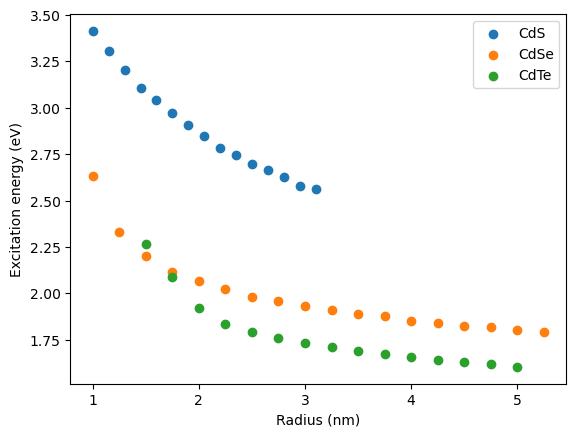

,filename,material,radius_nm,peak_wavelength_nm,excitation_energy_ev
0,CdS_r1.00nm.csv,CdS,1.00,363.1148,3.414457
1,CdS_r1.15nm.csv,CdS,1.15,375.1366,3.305036
2,CdS_r1.30nm.csv,CdS,1.30,387.1585,3.202409
3,CdS_r1.45nm.csv,CdS,1.45,399.1803,3.105965
4,CdS_r1.60nm.csv,CdS,1.60,407.1949,3.044832


In [16]:
for material, group in qd_summary.groupby("material"):
    plt.scatter(group["radius_nm"], group["excitation_energy_ev"], label=material)

plt.xlabel("Radius (nm)")
plt.ylabel("Excitation energy (eV)")
plt.legend()
plt.show()

qd_summary.head()

### Question 2 `10 points`

- P2: Decompose a data-analysis problem into a reusable workflow.
- C2: Relate quantum dot radius to excitation energy across many spectra.

1. What overall trend do you see between radius and excitation energy?
2. Do all three materials appear to follow the same curve, or do they seem systematically different? Support your answer with the plot you generated.


*Your answer here (`double click me!`):*

<br></br>

<a id="part3"></a>
## Part 3 - Modeling excitation energy vs radius

In a simple confinement picture, shrinking the quantum dot restricts the electron and hole to a smaller region of space. That tends to increase the characteristic excitation energy. In this section, you will compare two models.

- **Particle-in-a-box style model**: captures a leading confinement trend using an $r^{-2}$ dependence.
- **Your own model**: you will propose an extension and test whether it fits the data better.

### Coding Activity 3 `20 points`

- C3: Interpret models as capturing or neglecting physics for a given system.
- P3: Translate mathematical models into Python functions and compare them quantitatively.


#### Part 3A - Fit a particle-in-a-box style model

We will first fit

$$
E_\mathrm{PIB}(r) = E_\mathrm{gap} + \frac{h^2}{8\, m_e^*\, r^2}
$$

where $E_\mathrm{gap}$ is the bulk bandgap (eV), $m_e^*$ is the effective electron mass in units of the free electron mass $m_0$, and $r$ is the radius in nm (the diameter is twice the radius). 

This is not a full microscopic theory, but it gives a useful baseline.

**Your task:**
- Complete the PIB function
- Use the provided code to fit the curve. 
- *Leave comments on the provided curve fitting code explaining what it's doing.*

In [17]:
# Physical constant: ħ²/(2 m_e) in eV·nm²
HBAR2_OVER_2ME = 0.03810


def pib_model(r, Egap, me):
    """PIB confinement model: E = Egap + pi^2 * hbar^2 / (2 * me * r^2)."""
    r = np.asarray(r)
    return Egap + np.pi**2 * HBAR2_OVER_2ME / (me * r**2)

CdSe PIB:  Egap = 1.815 eV,  m_e* = 0.447 m0
           RMSE = 0.0297 eV,  R² = 0.9801


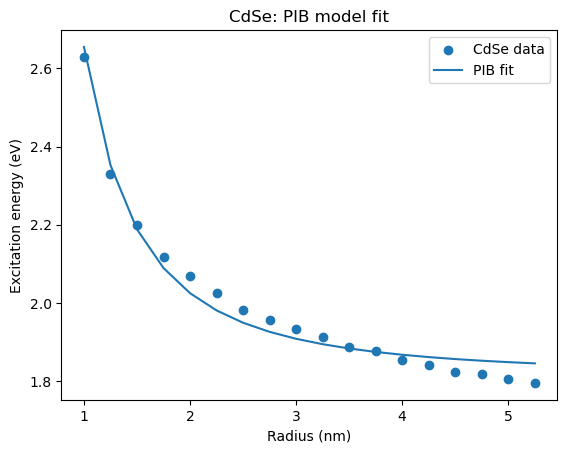

In [18]:
# --- Worked example: fit the PIB model to CdSe ---
# Subgoal: select and sort the CdSe subset.
group = qd_summary.query("material == 'CdSe'").sort_values("radius_nm") # YOUR COMMENT HERE
x = group["radius_nm"].to_numpy()
y = group["excitation_energy_ev"].to_numpy()

# Subgoal: fit with scipy.optimize.curve_fit; p0 provides initial guesses.
popt, _ = curve_fit( # YOUR COMMENT HERE
    pib_model,       # YOUR COMMENT HERE       
    x, y,            # YOUR COMMENT HERE
    p0=[1.7, 0.1]    # YOUR COMMENT HERE
    )
Egap, me = popt
y_fit = pib_model(x, *popt)

# COMPUTE FIT QUALITY METRICS
rmse = np.sqrt(np.mean((y - y_fit)**2))
r2 = 1 - np.sum((y - y_fit)**2) / np.sum((y - y.mean())**2)

# PRINT DATA 
print(f"CdSe PIB:  Egap = {Egap:.3f} eV,  m_e* = {me:.3f} m0")
print(f"           RMSE = {rmse:.4f} eV,  R² = {r2:.4f}")

# PLOTTING CODE
plt.scatter(x, y, label="CdSe data")
plt.plot(x, y_fit, label="PIB fit")
plt.xlabel("Radius (nm)")
plt.ylabel("Excitation energy (eV)")
plt.title("CdSe: PIB model fit")
plt.legend()
plt.show()

CdTe PIB:  Egap = 1.551 eV,  m_e* = 0.237 m0
           RMSE = 0.0136 eV,  R² = 0.9944


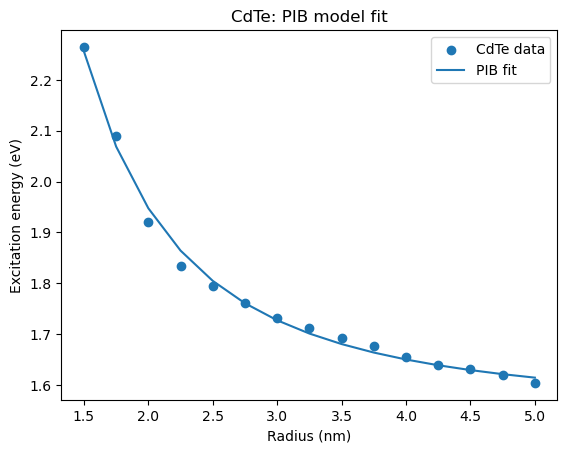

In [19]:
# Subgoal: Select and sort the CdTe subset.
group = qd_summary.query("material == 'CdTe'").sort_values("radius_nm")
x = group["radius_nm"].to_numpy()
y = group["excitation_energy_ev"].to_numpy()

# Subgoal: Fit with curve_fit.
popt, _ = curve_fit(pib_model, x, y, p0=[1.5, 0.1])
Egap, me = popt
y_fit = pib_model(x, *popt)

# Subgoal: Compute fit quality metrics.
rmse = np.sqrt(np.mean((y - y_fit)**2))
r2 = 1 - np.sum((y - y_fit)**2) / np.sum((y - y.mean())**2)

print(f"CdTe PIB:  Egap = {Egap:.3f} eV,  m_e* = {me:.3f} m0")
print(f"           RMSE = {rmse:.4f} eV,  R² = {r2:.4f}")

plt.scatter(x, y, label="CdTe data")
plt.plot(x, y_fit, label="PIB fit")
plt.xlabel("Radius (nm)")
plt.ylabel("Excitation energy (eV)")
plt.title("CdTe: PIB model fit")
plt.legend()
plt.show()

CdS PIB:  Egap = 2.565 eV,  m_e* = 0.384 m0
          RMSE = 0.0716 eV,  R² = 0.9240


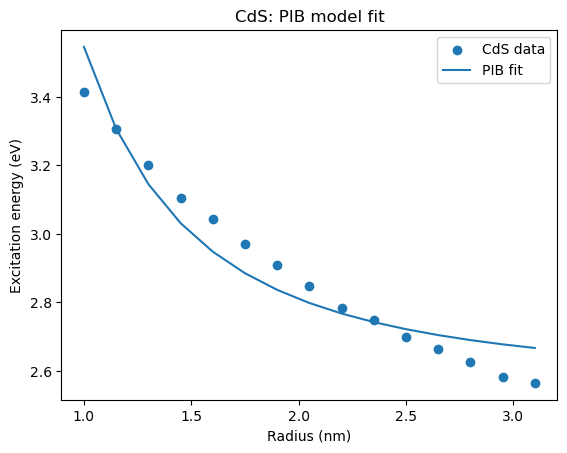

In [20]:
# Subgoal: Select and sort the CdS subset.
group = qd_summary.query("material == 'CdS'").sort_values("radius_nm")
x = group["radius_nm"].to_numpy()
y = group["excitation_energy_ev"].to_numpy()

# Subgoal: Fit with curve_fit.
popt, _ = curve_fit(pib_model, x, y, p0=[2.4, 0.2])
Egap, me = popt
y_fit = pib_model(x, *popt)

# Subgoal: Compute fit quality metrics.
rmse = np.sqrt(np.mean((y - y_fit)**2))
r2 = 1 - np.sum((y - y_fit)**2) / np.sum((y - y.mean())**2)

print(f"CdS PIB:  Egap = {Egap:.3f} eV,  m_e* = {me:.3f} m0")
print(f"          RMSE = {rmse:.4f} eV,  R² = {r2:.4f}")

plt.scatter(x, y, label="CdS data")
plt.plot(x, y_fit, label="PIB fit")
plt.xlabel("Radius (nm)")
plt.ylabel("Excitation energy (eV)")
plt.title("CdS: PIB model fit")
plt.legend()
plt.show()

#### Part 3B - Propose your own model

Create a new function that extends or modifies the PIB model. For example, you might add one extra term, change the sign structure, or test a different power of $r$. Fit your model and compare it to PIB.

Try your model on all three materials and see how the prediction compares to the PIB model. Pay particular attention to CdS.

In [21]:
# Example custom model: add a Coulomb-like 1/r correction term.
def custom_model(r, Egap, me, A):
    """PIB + Coulomb correction: adds A/r term."""
    r = np.asarray(r)
    return Egap + np.pi**2 * HBAR2_OVER_2ME / (me * r**2) - A / r

Custom model:  Egap = 1.588 eV,  m_e* = 0.207,  A = 0.198
               RMSE = 0.0129 eV,  R² = 0.9949


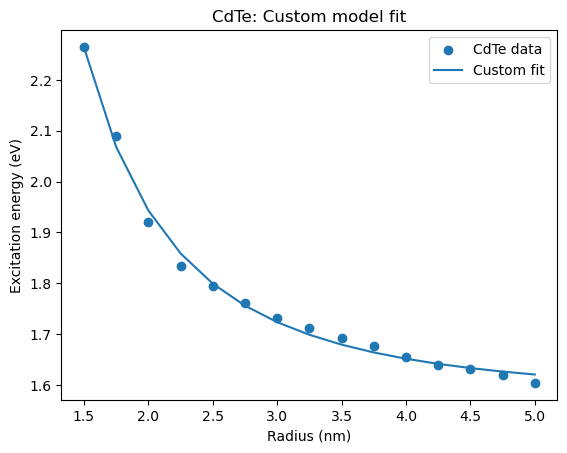

In [22]:
# Subgoal: Select one material to test on.
group = qd_summary.query("material == 'CdTe'").sort_values("radius_nm")
x = group["radius_nm"].to_numpy()
y = group["excitation_energy_ev"].to_numpy()

# Subgoal: Fit the custom model.
popt_custom, _ = curve_fit(custom_model, x, y, p0=[1.5, 0.1, 0.5])
y_custom = custom_model(x, *popt_custom)

rmse_custom = np.sqrt(np.mean((y - y_custom)**2))
r2_custom = 1 - np.sum((y - y_custom)**2) / np.sum((y - y.mean())**2)

print(f"Custom model:  Egap = {popt_custom[0]:.3f} eV,  m_e* = {popt_custom[1]:.3f},  A = {popt_custom[2]:.3f}")
print(f"               RMSE = {rmse_custom:.4f} eV,  R² = {r2_custom:.4f}")

plt.scatter(x, y, label="CdTe data")
plt.plot(x, y_custom, label="Custom fit")
plt.xlabel("Radius (nm)")
plt.ylabel("Excitation energy (eV)")
plt.title("CdTe: Custom model fit")
plt.legend()
plt.show()

### Question 3 `10 points`

- C3: Interpret models as capturing or neglecting physics for a given system.
- P3: Translate mathematical models into Python functions and compare them quantitatively.

1. For your material, how well did the PIB model fit the data? What does the optimized $E_\mathrm{gap}$ correspond to physically?
2. What change did you make in your custom model, and what physical effect might the extra term be trying to capture?
3. Did your custom model improve the fit for any of the materials? If so, do you think the improvement reflects additional physics, or could it be overfitting?

*Your answer here (`double click me!`):*

<br></br>

<a id="part4"></a>
## Part 4 - Classification with machine learning

You now have a compact data table with one row per spectrum. In this part, you will use **radius** and **excitation energy** as features to predict whether a quantum dot is **CdS**, **CdSe**, or **CdTe**.

### Coding Activity 4 `10 points`

- P1: Use Scikit-Learn to perform a classification task.
- C4: Compare how different materials can or cannot be distinguished from measured quantities.


#### Part 4A - Train/test split and a first model

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

X = qd_summary[["radius_nm", "excitation_energy_ev"]].values
y = qd_summary["material"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=7, stratify=y
)

classification_model = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=3)
)
classification_model.fit(X_train, y_train)

y_test_pred = classification_model.predict(X_test)
print(f"Test accuracy: {accuracy_score(y_test, y_test_pred):.3f}")

Test accuracy: 0.667


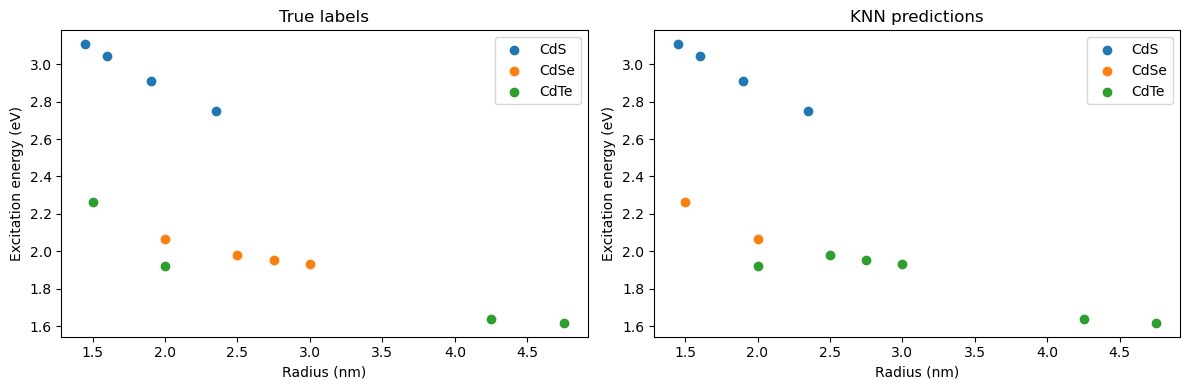

In [24]:
# Show true labels and model predictions side by side.
plot_predictions_vs_truth(X_test, y_test, y_test_pred, "KNN")

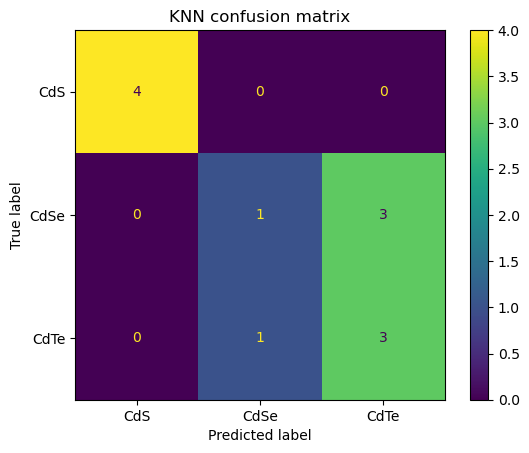

In [25]:
cm = confusion_matrix(y_test, y_test_pred, labels=np.unique(y))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y))
disp.plot()
plt.title("KNN confusion matrix")
plt.show()

#### Part 4B - Try another classifier

Try at least one additional classifier. Suggested options are **logistic regression** and **random forest**.

In [26]:
# Subgoal: Define variables.
X = qd_summary[["radius_nm", "excitation_energy_ev"]].values
y = qd_summary["material"].values

# Subgoal: Generate training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=7, stratify=y
)

# Subgoal: Choose a model.
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=500))

In [27]:
# Subgoal: Fit the model to the training data.
model.fit(X_train, y_train)

# Subgoal: Predict test set y values.
y_test_pred = model.predict(X_test)
print(f"Test accuracy: {accuracy_score(y_test, y_test_pred):.3f}")

Test accuracy: 0.917


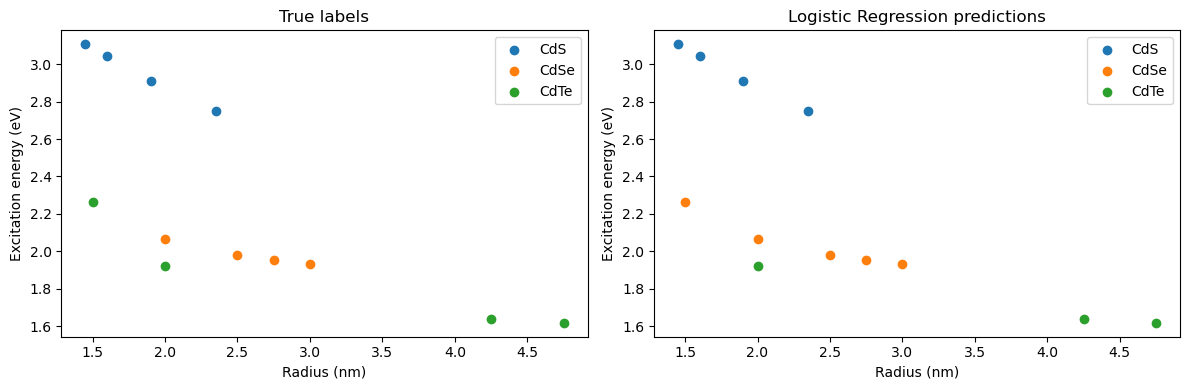

In [28]:
# Compare model predictions and true labels.
plot_predictions_vs_truth(X_test, y_test, y_test_pred, "Logistic Regression")

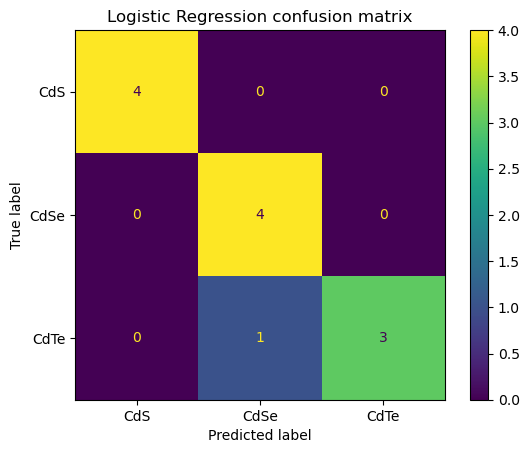

In [29]:
# Generate a confusion matrix.
cm = confusion_matrix(y_test, y_test_pred, labels=np.unique(y))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y))
disp.plot()
plt.title("Logistic Regression confusion matrix")
plt.show()

### Question 4 `10 points`

- P1: Use Scikit-Learn to perform a classification task.
- C4: Compare how different materials can or cannot be distinguished from measured quantities.

1. Why is it important to evaluate a classifier on a **test set** instead of only on the data used for training?
2. Which material pair seems hardest to distinguish from these two features alone?
3. What additional experimental or computed feature might improve classification?


*Your answer here (`double click me!`):*

<br></br>

<a id="reflection"></a>
## Reflection `10 points`

Use this section to connect the programming workflow to the chemistry ideas of the lab.

1. How did the progression from individual spectra to a summary table change the kinds of questions you were able to ask?
2. In this lab, where did a simple model help you understand the chemistry, and where did it hide important physics?
3. How could you use the techniques demonstrated in this lab in your work or research? Give a specific example.

*Your answer here (`double click me!`):*

<br></br>

## References

Spectra in this lab are synthetic data generated to reproduce size-dependent emission trends reported in:

Yu, W. W.; Qu, L.; Guo, W.; Peng, X. Experimental Determination of the Extinction Coefficient of CdTe, CdSe, and CdS Nanocrystals. *Chem. Mater.* **2003**, *15* (14), 2854–2860. https://doi.org/10.1021/cm034081k